# Tanh Policy Verification and Rashomon Sets

This tutorial demonstrates a compact end-to-end workflow for a neural policy with `torch.nn.Tanh` activations:

1. load a Tanh policy checkpoint,
2. verify the policy with IBP, CROWN, Alpha-CROWN, and zonotope parameter bounds,
3. compute a Rashomon parameter box with `IntervalTrainer`, then certify that box with the available methods.

The MIP verifier is intentionally not used here because the current MIP implementation supports `Linear`/`ReLU` networks, not Tanh networks.

In [1]:
from __future__ import annotations

import copy
import sys
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in (start, *start.parents):
        if (candidate / 'core').is_dir() and (candidate / 'tutorials').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root from the current working directory.')


REPO_ROOT = find_repo_root()
CORE_DIR = REPO_ROOT / 'core'
if str(CORE_DIR) not in sys.path:
    sys.path.insert(0, str(CORE_DIR))

from abstract_gradient_training.bounded_models import CROWNBoundedModel, IntervalBoundedModel
from src.interval_utils import _bounded_model_width
from src.trainer.IntervalTrainer import IntervalTrainer
from src.verification.interval_tensor import IntervalTensor
from src.verification.verify import bound_accuracy, bound_forward_pass

SEED = 7
DTYPE = torch.float64
DEVICE = torch.device('cpu')
torch.manual_seed(SEED)
torch.set_default_dtype(DTYPE)

REPO_ROOT

PosixPath('/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning')

## 1. Load a Tanh Policy

For a self-contained tutorial, this cell creates a small deterministic checkpoint the first time it runs, then loads it as a normal policy checkpoint. Replace `POLICY_PATH` with your own checkpoint if you want to run the same workflow on a trained policy.

In [2]:
INPUT_DIM = 2
HIDDEN_DIM = 8
N_ACTIONS = 3
POLICY_PATH = REPO_ROOT / 'tutorials' / 'artifacts' / 'tanh_policy.pt'


def build_tanh_policy() -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(INPUT_DIM, HIDDEN_DIM),
        nn.Tanh(),
        nn.Linear(HIDDEN_DIM, N_ACTIONS),
    ).to(dtype=DTYPE, device=DEVICE)


def initialise_tutorial_policy(policy: nn.Sequential) -> None:
    # Hand-coded high-confidence Tanh features. This keeps the tutorial fast and deterministic.
    with torch.no_grad():
        first: nn.Linear = policy[0]
        last: nn.Linear = policy[2]
        first.weight.copy_(
            torch.tensor(
                [
                    [5.0, 0.0],
                    [0.0, 5.0],
                    [-5.0, 0.0],
                    [0.0, -5.0],
                    [3.0, 3.0],
                    [3.0, -3.0],
                    [-3.0, 3.0],
                    [-3.0, -3.0],
                ],
                dtype=DTYPE,
            )
        )
        first.bias.zero_()
        last.weight.copy_(
            torch.tensor(
                [
                    [2.0, -0.5, -1.0, 0.2, 0.8, 0.4, -0.3, -0.2],
                    [-0.4, 2.0, 0.2, -1.0, 0.2, -0.4, 0.8, -0.3],
                    [-1.0, -0.7, 1.5, 1.2, -0.5, -0.2, -0.2, 0.8],
                ],
                dtype=DTYPE,
            )
        )
        last.bias.copy_(torch.tensor([0.15, 0.05, -0.05], dtype=DTYPE))


if not POLICY_PATH.exists():
    POLICY_PATH.parent.mkdir(parents=True, exist_ok=True)
    policy_to_save = build_tanh_policy()
    initialise_tutorial_policy(policy_to_save)
    torch.save(policy_to_save.state_dict(), POLICY_PATH)

policy = build_tanh_policy()
policy.load_state_dict(torch.load(POLICY_PATH, map_location=DEVICE))
policy.eval()

print(policy)
print('Contains Tanh:', any(isinstance(module, nn.Tanh) for module in policy))
print('Loaded checkpoint:', POLICY_PATH)

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): Tanh()
  (2): Linear(in_features=8, out_features=3, bias=True)
)
Contains Tanh: True
Loaded checkpoint: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/tutorials/artifacts/tanh_policy.pt


## 2. Build a Surrogate Dataset

The labels below are the policy's own argmax actions. This mirrors a common Rashomon-set use case: define the set of parameter perturbations that preserve the source policy's decisions on a certification dataset.

In [3]:
def make_policy_dataset(model: nn.Module, n: int = 256, seed: int = SEED) -> TensorDataset:
    generator = torch.Generator().manual_seed(seed)
    inputs = 2.0 * torch.rand((n, INPUT_DIM), generator=generator, dtype=DTYPE, device=DEVICE) - 1.0
    with torch.no_grad():
        targets = model(inputs).argmax(dim=1)
    return TensorDataset(inputs, targets)


dataset = make_policy_dataset(policy, n=256)
verify_inputs, verify_targets = dataset.tensors[0][:64], dataset.tensors[1][:64]
with torch.no_grad():
    logits = policy(verify_inputs)
    nominal_acc = (logits.argmax(dim=1) == verify_targets).double().mean().item()
    counts = torch.bincount(verify_targets, minlength=N_ACTIONS)

print('Nominal self-label accuracy:', nominal_acc)
print('Action counts in verification split:', counts.tolist())

Nominal self-label accuracy: 1.0
Action counts in verification split: [21, 22, 21]


In [4]:
def print_rows(rows: list[dict], columns: list[str]) -> None:
    widths = {col: max(len(col), *(len(str(row.get(col, ''))) for row in rows)) for col in columns}
    print(' | '.join(col.ljust(widths[col]) for col in columns))
    print('-+-'.join('-' * widths[col] for col in columns))
    for row in rows:
        print(' | '.join(str(row.get(col, '')).ljust(widths[col]) for col in columns))


def margin_certificate(logits_l: torch.Tensor, logits_u: torch.Tensor, targets: torch.Tensor) -> tuple[float, bool]:
    target_lower = logits_l.gather(1, targets.reshape(-1, 1)).squeeze(1)
    competitor_upper = logits_u.clone()
    competitor_upper.scatter_(1, targets.reshape(-1, 1), -torch.inf)
    margin = target_lower - competitor_upper.max(dim=1).values
    return float(margin.min().detach().cpu()), bool((margin > 0).all().item())


def lower_bound_accuracy(logits_l: torch.Tensor, logits_u: torch.Tensor, targets: torch.Tensor) -> float:
    return float(bound_accuracy(IntervalTensor(logits_l, logits_u), targets).detach().cpu())


def make_input_verifier(model: nn.Sequential, method: str):
    model = copy.deepcopy(model).eval()
    if method == 'ibp':
        return IntervalBoundedModel(model, trainable=False)
    if method == 'crown':
        return CROWNBoundedModel(model, trainable=False, relu_relaxation='parallel')
    if method == 'alpha_crown':
        return CROWNBoundedModel(
            model,
            trainable=False,
            relu_relaxation='optimizable',
            tanh_relaxation='optimizable',
            alpha_crown_iters=20,
            alpha_crown_lr=0.1,
        )
    raise ValueError(f'Unknown verifier method: {method}')

## 3. Verify an Input Region

IBP, CROWN, and Alpha-CROWN bound the policy outputs over an input box. The target action is the policy's action at the box center. Alpha-CROWN uses the new optimizable Tanh relaxation.

In [5]:
with torch.no_grad():
    all_logits = policy(verify_inputs)
    top2 = torch.topk(all_logits, k=2, dim=1).values
    center_idx = int((top2[:, 0] - top2[:, 1]).argmax().item())

center = verify_inputs[center_idx : center_idx + 1]
target = verify_targets[center_idx : center_idx + 1]
radius = torch.full_like(center, 0.02)
input_l = (center - radius).clamp(min=-1.0)
input_u = (center + radius).clamp(max=1.0)

rows = []
for method in ['ibp', 'crown', 'alpha_crown']:
    verifier = make_input_verifier(policy, method)
    logits_l, logits_u = verifier.bound_forward(input_l, input_u)
    margin, certified = margin_certificate(logits_l, logits_u, target)
    rows.append(
        {
            'method': method,
            'target': int(target.item()),
            'certified': certified,
            'margin': f'{margin:.5f}',
            'logit_lower': [round(v, 4) for v in logits_l.squeeze(0).tolist()],
            'logit_upper': [round(v, 4) for v in logits_u.squeeze(0).tolist()],
        }
    )

print('Input box lower:', input_l.squeeze(0).tolist())
print('Input box upper:', input_u.squeeze(0).tolist())
print_rows(rows, ['method', 'target', 'certified', 'margin', 'logit_lower', 'logit_upper'])

Input box lower: [-0.5751715532854431, -0.6684056293895446]
Input box upper: [-0.5351715532854431, -0.6284056293895446]
method      | target | certified | margin  | logit_lower                | logit_upper               
------------+--------+-----------+---------+----------------------------+---------------------------
ibp         | 2      | True      | 8.42846 | [-3.0216, -3.3032, 5.5727] | [-2.8558, -3.0317, 5.6722]
crown       | 2      | True      | 8.46978 | [-3.0218, -3.3076, 5.6162] | [-2.8536, -3.0318, 5.6292]
alpha_crown | 2      | True      | 8.47170 | [-3.0213, -3.3032, 5.6157] | [-2.856, -3.0319, 5.6296] 


In [6]:
rows

[{'method': 'ibp',
  'target': 2,
  'certified': True,
  'margin': '8.42846',
  'logit_lower': [-3.0216, -3.3032, 5.5727],
  'logit_upper': [-2.8558, -3.0317, 5.6722]},
 {'method': 'crown',
  'target': 2,
  'certified': True,
  'margin': '8.46978',
  'logit_lower': [-3.0218, -3.3076, 5.6162],
  'logit_upper': [-2.8536, -3.0318, 5.6292]},
 {'method': 'alpha_crown',
  'target': 2,
  'certified': True,
  'margin': '8.47170',
  'logit_lower': [-3.0213, -3.3032, 5.6157],
  'logit_upper': [-2.856, -3.0319, 5.6296]}]

In [9]:
import pandas as pd

In [11]:
pd.DataFrame(rows)

,method,target,certified,margin,logit_lower,logit_upper
0,ibp,2,True,8.42846,"[-3.0216, -3.3032, 5.5727]","[-2.8558, -3.0317, 5.6722]"
1,crown,2,True,8.46978,"[-3.0218, -3.3076, 5.6162]","[-2.8536, -3.0318, 5.6292]"
2,alpha_crown,2,True,8.47170,"[-3.0213, -3.3032, 5.6157]","[-2.856, -3.0319, 5.6296]"


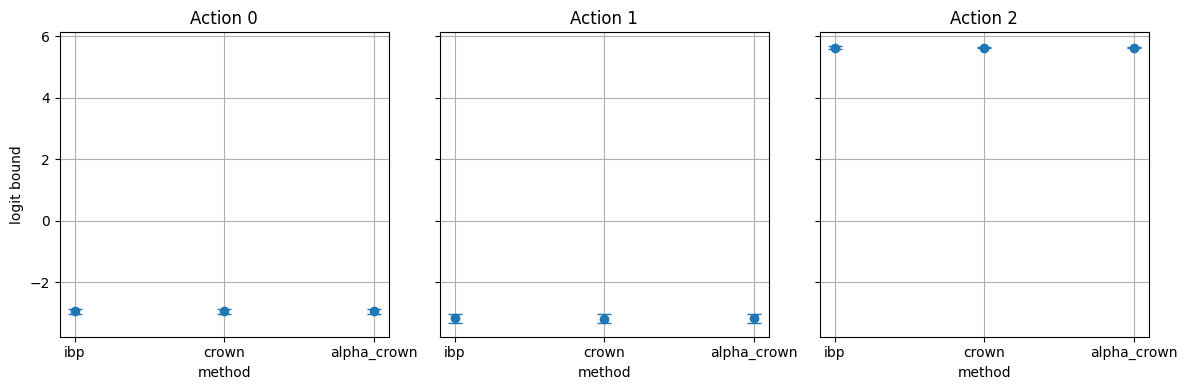

In [12]:
import numpy as np

import matplotlib.pyplot as plt

methods = [row['method'] for row in rows]
x = np.arange(len(methods))
n_actions = len(rows[0]['logit_lower'])

fig, axes = plt.subplots(1, n_actions, figsize=(12, 4), sharey=True)

for action in range(n_actions):
    lowers = [row['logit_lower'][action] for row in rows]
    uppers = [row['logit_upper'][action] for row in rows]
    mids = [(l + u) / 2 for l, u in zip(lowers, uppers)]
    errs = [(u - l) / 2 for l, u in zip(lowers, uppers)]
    ax = axes[action]
    ax.errorbar(x, mids, yerr=errs, fmt='o', capsize=5)
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_title(f'Action {action}')
    ax.set_xlabel('method')
    if action == 0:
        ax.set_ylabel('logit bound')
    ax.grid(True)

plt.tight_layout()
plt.show()

## 4. Zonotope Parameter Verification

The zonotope verifier in this repo represents parameter uncertainty rather than input boxes. The cell below verifies the loaded Tanh policy under a small independent box around every parameter, using one zonotope generator per scalar parameter.

In [13]:
def flat_parameter_count(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters())


def zonotope_parameter_generators(model: nn.Module, radius: float) -> tuple[torch.Tensor, IntervalTensor]:
    n_params = flat_parameter_count(model)
    generators = torch.eye(n_params, dtype=DTYPE, device=DEVICE) * radius
    coefficients = IntervalTensor(-torch.ones(n_params, dtype=DTYPE), torch.ones(n_params, dtype=DTYPE))
    return generators, coefficients


param_radius = 1e-3
generators, coefficients = zonotope_parameter_generators(policy, radius=param_radius)
zonotope_logits = bound_forward_pass(policy, generators, coefficients, verify_inputs, use_zonotopes=True)
interval_logits = bound_forward_pass(policy, generators, coefficients, verify_inputs, use_zonotopes=False)

rows = []
for name, logits in [('zonotope', zonotope_logits), ('interval_parameters', interval_logits)]:
    rows.append(
        {
            'method': name,
            'param_radius': param_radius,
            'lower_bound_acc': f'{float(bound_accuracy(logits, verify_targets)):.3f}',
            'mean_logit_width': f'{float((logits.ub - logits.lb).mean()):.5f}',
        }
    )

print_rows(rows, ['method', 'param_radius', 'lower_bound_acc', 'mean_logit_width'])

method              | param_radius | lower_bound_acc | mean_logit_width
--------------------+--------------+-----------------+-----------------
zonotope            | 0.001        | 1.000           | 0.01953         
interval_parameters | 0.001        | 1.000           | 0.01953         


/tmp/ipykernel_1697608/2058880331.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  'mean_logit_width': f'{float((logits.ub - logits.lb).mean()):.5f}',


## 5. Compute Rashomon Sets

`IntervalTrainer.compute_rashomon_set` currently constructs Rashomon boxes with IBP. After each box is computed, this notebook copies the same parameter interval into IBP, CROWN, and Alpha-CROWN bounded models, and also converts it into a parameter zonotope for a post-hoc zonotope certificate.

In [14]:
def copy_box_to_verifier(model: nn.Sequential, box: IntervalBoundedModel, method: str):
    model = copy.deepcopy(model).eval()
    if method == 'ibp':
        verifier = IntervalBoundedModel(model, trainable=True)
    elif method == 'crown':
        verifier = CROWNBoundedModel(model, trainable=True, relu_relaxation='parallel')
    elif method == 'alpha_crown':
        verifier = CROWNBoundedModel(
            model,
            trainable=True,
            relu_relaxation='optimizable',
            tanh_relaxation='optimizable',
            alpha_crown_iters=10,
            alpha_crown_lr=0.1,
        )
    else:
        raise ValueError(f'Unknown verifier method: {method}')

    for dst, src in zip(verifier.param_l, box.param_l):
        dst.data.copy_(src.detach())
    for dst, src in zip(verifier.param_u, box.param_u):
        dst.data.copy_(src.detach())
    return verifier


def center_model_and_zonotope_from_box(model: nn.Sequential, box: IntervalBoundedModel):
    center_model = copy.deepcopy(model).eval()
    radii = []
    with torch.no_grad():
        for param, lower, upper in zip(center_model.parameters(), box.param_l, box.param_u):
            midpoint = (lower + upper) / 2
            radius = ((upper - lower) / 2).clamp(min=0)
            param.copy_(midpoint)
            radii.append(radius.reshape(-1))
    flat_radii = torch.cat(radii)
    generators = torch.diag(flat_radii)
    coefficients = IntervalTensor(-torch.ones_like(flat_radii), torch.ones_like(flat_radii))
    return center_model, generators, coefficients


def certify_parameter_box(model: nn.Sequential, box: IntervalBoundedModel, method: str, inputs: torch.Tensor, targets: torch.Tensor) -> dict:
    if method == 'zonotope':
        center_model, generators, coefficients = center_model_and_zonotope_from_box(model, box)
        logits = bound_forward_pass(center_model, generators, coefficients, inputs, use_zonotopes=True)
        acc = float(bound_accuracy(logits, targets))
        width = float((logits.ub - logits.lb).mean())
    else:
        verifier = copy_box_to_verifier(model, box, method)
        logits_l, logits_u = verifier.bound_forward(inputs, inputs)
        acc = lower_bound_accuracy(logits_l, logits_u, targets)
        width = float((logits_u - logits_l).mean().detach().cpu())
    return {'method': method, 'lower_bound_acc': f'{acc:.3f}', 'mean_logit_width': f'{width:.5f}'}

In [15]:
RASHOMON_RUNS = {
    'width_objective': {'obj_alpha': 0.0},
    'log_volume_objective': {'obj_alpha': 0.75},
}
RASHOMON_ITERS = 20
RASHOMON_MIN_ACC = 0.55

rashomon_rows = []
rashomon_boxes = {}

for run_name, extra_kwargs in RASHOMON_RUNS.items():
    print(f'\nComputing Rashomon set: {run_name}')
    trainer = IntervalTrainer(
        model=copy.deepcopy(policy).cpu(),
        min_acc_limit=RASHOMON_MIN_ACC,
        min_soft_acc_limit=RASHOMON_MIN_ACC,
        min_hard_acc_limit=RASHOMON_MIN_ACC,
        min_acc_increment=0.0,
        seed=SEED,
        n_certificate_samples=64,
        n_iters=RASHOMON_ITERS,
        batch_size=64,
        checkpoint=-1,
        primal_learning_rate=0.1,
        dual_learning_rate=0.1,
        penalty_coefficient=1.0,
        use_schedule=True,
        init_bbox=0.0,
        T=10.0,
        **extra_kwargs,
    )
    trainer.compute_rashomon_set(dataset, use_outer_bbox=False)
    box = trainer.bounds[-1]
    rashomon_boxes[run_name] = box
    box_width = float(_bounded_model_width(box).detach().cpu())
    trainer_cert = trainer.certificates[-1] if trainer.certificates else None

    for method in ['ibp', 'crown', 'alpha_crown', 'zonotope']:
        row = certify_parameter_box(policy, box, method, verify_inputs, verify_targets)
        row.update(
            {
                'rashomon_run': run_name,
                'box_width': f'{box_width:.5f}',
                'trainer_cert': None if trainer_cert is None else f'{trainer_cert:.3f}',
            }
        )
        rashomon_rows.append(row)

print_rows(
    rashomon_rows,
    ['rashomon_run', 'method', 'box_width', 'trainer_cert', 'lower_bound_acc', 'mean_logit_width'],
)


Computing Rashomon set: width_objective
Initial acc constraint violation: -0.4378 (Positive = violated)
Number of model parameters: 51
Computing Rashomon set with limits: min_soft_acc_limit=0.55, min_hard_acc_limit=0.55
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=0.99


100%|██████████| 20/20 [00:00<00:00, 68.83it/s, size=11.45, obj=0.201, min_soft_acc=0.901]
[AGT] [WARNING ] [17:20:18] Tanh CROWN bounds encountered mixed-sign intervals. Using a sound single-affine residual fallback; bounds may be looser than split-domain bounds.


Final bbox:  Obj=0.22,  Size=11.45,  Min acc hard=0.72,  Min acc soft=0.72
Computing final certificates over 64 samples
Num cert samples: 64
----------------------- Finished Computing Rashomon set ------------------------

Computing Rashomon set: log_volume_objective
Initial acc constraint violation: -0.4378 (Positive = violated)
Number of model parameters: 51
Computing Rashomon set with limits: min_soft_acc_limit=0.55, min_hard_acc_limit=0.55
Initial bbox:  Obj=-10.36,  Size=0.00,  Min acc hard=1.00,  Min acc soft=0.99


100%|██████████| 20/20 [00:00<00:00, 84.71it/s, size=2.01, obj=-2.446, min_soft_acc=0.999]


Final bbox:  Obj=-2.41,  Size=2.01,  Min acc hard=0.95,  Min acc soft=0.94
Computing final certificates over 64 samples
Num cert samples: 64
----------------------- Finished Computing Rashomon set ------------------------
rashomon_run         | method      | box_width | trainer_cert | lower_bound_acc | mean_logit_width
---------------------+-------------+-----------+--------------+-----------------+-----------------
width_objective      | ibp         | 11.45499  | 0.719        | 0.672           | 2.26963         
width_objective      | crown       | 11.45499  | 0.719        | 0.594           | 2.94328         
width_objective      | alpha_crown | 11.45499  | 0.719        | 0.641           | 2.74038         
width_objective      | zonotope    | 11.45499  | 0.719        | 0.672           | 2.30457         
log_volume_objective | ibp         | 2.01437   | 0.953        | 1.000           | 0.38820         
log_volume_objective | crown       | 2.01437   | 0.953        | 0.969           | 0.5

## Notes

- IBP is usually fastest and loosest.
- CROWN and Alpha-CROWN use affine relaxations. Alpha-CROWN optimizes relaxation parameters, including the Tanh slopes added in this branch.
- The zonotope verifier shown here is for parameter uncertainty and preserves some shared-generator correlations.
- `IntervalTrainer.compute_rashomon_set` currently optimizes an IBP parameter box; the later certification step compares that same box across the available verification methods.